# 경주 관광 코스 추천 시스템 분석

## 데이터 개요
- TourSpot: 662개 관광지 (좌표, 내용, 타입 등)
- AccommodationDetail: 330개 숙박 객실 정보

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

C:\Users\chaet\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\chaet\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# 데이터 로드
df_tour = pd.read_csv("_TourSpot__202607062337.csv")
df_accom = pd.read_csv("_AccommodationDetail__202607062338.csv")

print(f"관광지 데이터: {len(df_tour)}개")
print(f"숙박 데이터: {len(df_accom)}개")
print(f"\n관광지 컬럼: {df_tour.columns.tolist()}")
print(f"\n숙박 컬럼: {df_accom.columns.tolist()}")

관광지 데이터: 662개
숙박 데이터: 330개

관광지 컬럼: ['spot_id', 'name', 'img', 'content', 'address', 'can_parking', 'can_pet', 'crowd_level', 'overview', 'homepage', 'map_x', 'map_y', 'content_id', 'content_type_id', 'tel']

숙박 컬럼: ['temp_room_id', 'spot_id', 'room_code', 'room_title', 'room_size_pyeong', 'room_size_square_meter', 'room_count', 'base_count', 'max_count', 'offseason_weekday_min_fee', 'offseason_weekend_min_fee', 'peak_season_weekday_min_fee', 'peak_season_weekend_min_fee', 'room_intro', 'has_bath_facility', 'has_bath', 'has_home_theater', 'has_air_condition', 'has_tv', 'has_pc', 'has_cable', 'has_internet', 'has_refrigerator', 'has_toiletries', 'has_sofa', 'has_cook', 'has_table', 'has_hairdryer']


## 1. 데이터 탐색

In [3]:
# 관광지 타입 분포 확인
print("=== 관광지 타입 분포 (content_type_id) ===")
print(df_tour['content_type_id'].value_counts())

# 좌표 데이터 확인
print(f"\n좌표 있는 데이터: {df_tour[['map_x', 'map_y']].notna().all(axis=1).sum()}개")
print(f"좌표 없는 데이터: {df_tour[['map_x', 'map_y']].isna().any(axis=1).sum()}개")

# 반려동물/주차 가능 데이터 확인
print(f"\n반려동물 정보 있음: {df_tour['can_pet'].notna().sum()}개")
print(f"주차 정보 있음: {df_tour['can_parking'].notna().sum()}개")

=== 관광지 타입 분포 (content_type_id) ===
content_type_id
39    212
12    202
32    109
28     53
14     32
38     31
25     16
15      7
Name: count, dtype: int64

좌표 있는 데이터: 662개
좌표 없는 데이터: 0개

반려동물 정보 있음: 0개
주차 정보 있음: 0개


In [4]:
# 텍스트 데이터 확인 (임베딩 가능 여부)
print("=== 텍스트 데이터 현황 ===")
print(f"overview 있음: {df_tour['overview'].notna().sum()}개")
print(f"content 있음: {df_tour['content'].notna().sum()}개")
print(f"name만 있음: {df_tour['name'].notna().sum()}개")

# 샘플 overview 확인
print("\n=== Overview 샘플 ===")
print(df_tour[df_tour['overview'].notna()]['overview'].iloc[0][:200])

=== 텍스트 데이터 현황 ===
overview 있음: 661개
content 있음: 0개
name만 있음: 662개

=== Overview 샘플 ===
라라캠핑장은 경북 경주시 양남면 신대리에 자리 잡았다. 경주시청을 기점으로 40㎞가량 떨어졌다. 자동차를 타고 신대로와 서왕길을 번갈아 달리면 닿는다. 도착까지 걸리는 시간은 60분 안팎이다. 캠핑장은 산속 숲에 위치한 덕분에 더없이 자연친화적인 느낌이다. 인근에 계곡이 있어 물놀이로 한여름 무더위를 날리기 좋다. 캠핑장에는 파쇄석으로 이뤄진 오토캠핑 사이


## 2. 좌표 시각화

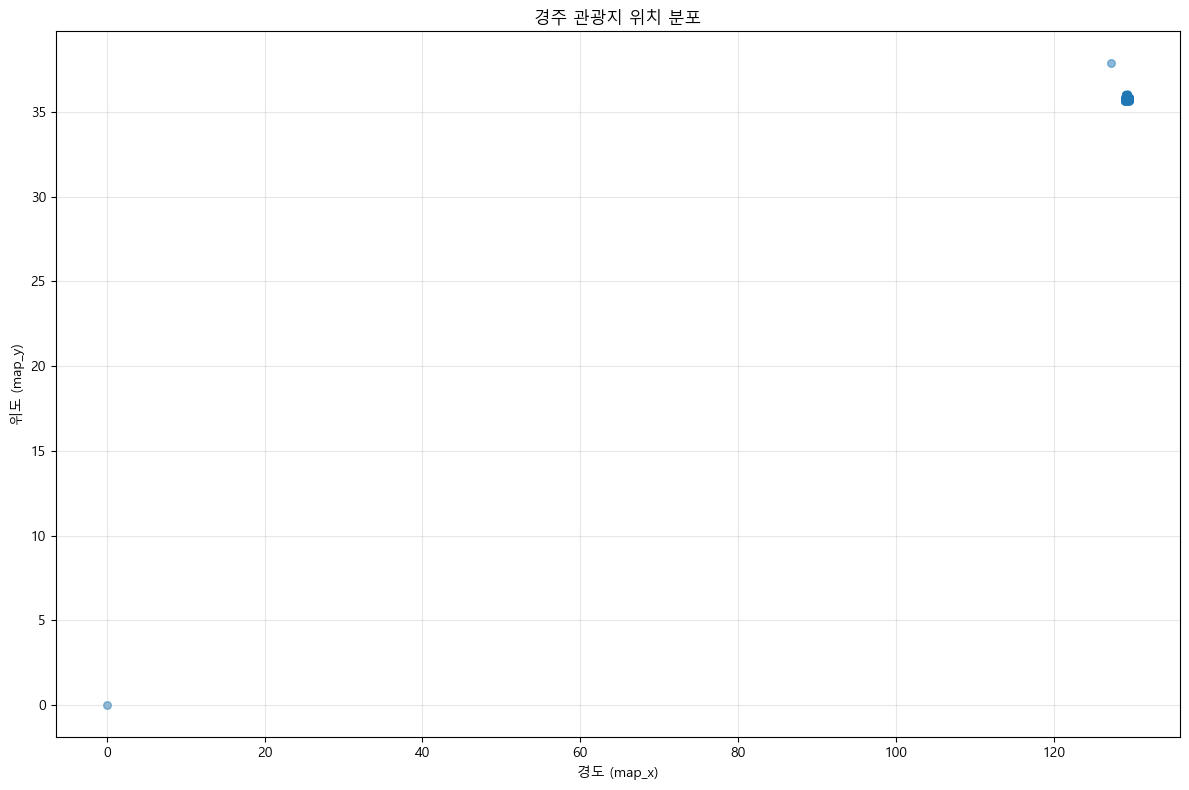

좌표 범위:
경도: 0.0000 ~ 129.5125
위도: 0.0000 ~ 37.8590


In [5]:
# 관광지 위치 분포 시각화
df_valid = df_tour[df_tour[['map_x', 'map_y']].notna().all(axis=1)]

plt.figure(figsize=(12, 8))
plt.scatter(df_valid['map_x'], df_valid['map_y'], alpha=0.5, s=30)
plt.xlabel('경도 (map_x)')
plt.ylabel('위도 (map_y)')
plt.title('경주 관광지 위치 분포')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"좌표 범위:")
print(f"경도: {df_valid['map_x'].min():.4f} ~ {df_valid['map_x'].max():.4f}")
print(f"위도: {df_valid['map_y'].min():.4f} ~ {df_valid['map_y'].max():.4f}")

## 3. 거리 계산 함수 (Haversine)

In [6]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    두 지점 간의 거리를 km 단위로 계산 (Haversine 공식)
    """
    R = 6371  # 지구 반지름 (km)
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = R * c
    
    return distance

# 테스트
spot1 = df_valid.iloc[0]
spot2 = df_valid.iloc[1]
dist = haversine_distance(spot1['map_y'], spot1['map_x'], spot2['map_y'], spot2['map_x'])
print(f"테스트 거리: {dist:.2f} km")
print(f"{spot1['name']} <-> {spot2['name']}")

테스트 거리: 13.81 km
라라캠핑장 <-> 장터밥상


## 4. 이동 시간 추정 함수

In [7]:
def estimate_travel_time(distance_km, transport_mode):
    """
    거리와 이동 수단에 따른 예상 소요 시간 계산 (분 단위)
    
    transport_mode:
    - 'walk': 도보 (4km/h)
    - 'bicycle': 자전거 (15km/h)
    - 'public': 대중교통 (30km/h, 대기시간 +10분)
    - 'car': 자차 (50km/h)
    """
    speeds = {
        'walk': 4,
        'bicycle': 15,
        'public': 30,
        'car': 50
    }
    
    time_minutes = (distance_km / speeds[transport_mode]) * 60
    
    # 대중교통은 대기시간 추가
    if transport_mode == 'public':
        time_minutes += 10
    
    return time_minutes

# 테스트
print(f"10km 이동 시간:")
for mode in ['walk', 'bicycle', 'public', 'car']:
    time = estimate_travel_time(10, mode)
    print(f"  {mode}: {time:.1f}분")

10km 이동 시간:
  walk: 150.0분
  bicycle: 40.0분
  public: 30.0분
  car: 12.0분


## 5. 시간 예산 계산

In [8]:
def get_time_budget(duration_type):
    """
    여행 기간에 따른 시간 예산 계산 (분 단위)
    관광 시간 = 총 시간 - 식사/휴식 시간
    """
    budgets = {
        'half_day': 4 * 60,      # 4시간
        'one_day': 8 * 60,       # 8시간
        'two_days': 16 * 60      # 1박2일: 16시간
    }
    return budgets.get(duration_type, 8 * 60)

print("시간 예산:")
for dur in ['half_day', 'one_day', 'two_days']:
    budget = get_time_budget(dur)
    print(f"  {dur}: {budget}분 ({budget/60:.1f}시간)")

시간 예산:
  half_day: 240분 (4.0시간)
  one_day: 480분 (8.0시간)
  two_days: 960분 (16.0시간)


## 6. 방문 시간 추정

In [9]:
def estimate_visit_duration(content_type_id):
    """
    관광지 타입별 예상 방문 시간 (분)
    content_type_id 기준 (한국관광공사 API 기준)
    """
    # 타입별 기본 체류 시간
    duration_map = {
        12: 60,   # 관광지 (사찰, 유적지 등)
        14: 90,   # 문화시설 (박물관, 미술관)
        15: 120,  # 축제/행사
        25: 45,   # 여행코스
        28: 180,  # 레포츠 (캠핑 등)
        32: 30,   # 숙박
        38: 60,   # 쇼핑
        39: 60,   # 음식점
    }
    return duration_map.get(content_type_id, 60)  # 기본 60분

# 데이터에 체류시간 추가
df_tour['visit_duration'] = df_tour['content_type_id'].apply(estimate_visit_duration)

print("타입별 평균 체류시간:")
print(df_tour.groupby('content_type_id')['visit_duration'].first().sort_index())

타입별 평균 체류시간:
content_type_id
12     60
14     90
15    120
25     45
28    180
32     30
38     60
39     60
Name: visit_duration, dtype: int64
